# Tool Comparison: Hunspell vs SymSpell vs LanguageTool
High-level flagging rates and inter-tool agreement across the full dataset and a cleaned subset.

In [6]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/full_results2.db')

df = pd.read_sql(
    """
    SELECT
        name,
        name_script,
        hunspell_orig_known,
        hunspell_latin_known,
        symspell_orig_known,
        symspell_latin_known,
        lt_auto_orig_known,
        lt_auto_latin_known
    FROM names
    """,
    engine
)

# Ensure boolean dtype
bool_cols = [
    'hunspell_orig_known', 'hunspell_latin_known',
    'symspell_orig_known', 'symspell_latin_known',
    'lt_auto_orig_known',       'lt_auto_latin_known',
]
df[bool_cols] = df[bool_cols].astype(bool)

print(f'Loaded {len(df):,} rows')

Loaded 727,352 rows


## 1. Full dataset

In [7]:
def flagging_summary(frame, label=''):
    """Per-tool flagging rates for both conditions."""
    n = len(frame)
    rows = []
    for tool, orig_col, latin_col in [
        ('Hunspell',     'hunspell_orig_known', 'hunspell_latin_known'),
        ('SymSpell',     'symspell_orig_known', 'symspell_latin_known'),
        ('LanguageTool', 'lt_auto_orig_known',       'lt_auto_latin_known'),
    ]:
        orig_known  = frame[orig_col].sum()
        latin_known = frame[latin_col].sum()
        rows.append({
            'Tool':             tool,
            'Orig known':       f'{orig_known:,}',
            'Orig flagged':     f'{n - orig_known:,}',
            'Orig flag %':      f'{100*(n - orig_known)/n:.1f}%',
            'Latin known':      f'{latin_known:,}',
            'Latin flagged':    f'{n - latin_known:,}',
            'Latin flag %':     f'{100*(n - latin_known)/n:.1f}%',
        })
    summary = pd.DataFrame(rows).set_index('Tool')
    print(f'  n = {n:,}  {label}')
    return summary

flagging_summary(df, label='(full dataset)')

  n = 727,352  (full dataset)


,Orig known,Orig flagged,Orig flag %,Latin known,Latin flagged,Latin flag %
Tool,,,,,,
Hunspell,"18,834","708,518",97.4%,"27,999","699,353",96.2%
SymSpell,"14,999","712,353",97.9%,"23,735","703,617",96.7%
LanguageTool,"146,809","580,543",79.8%,"116,222","611,130",84.0%


In [8]:
def agreement_table(frame, condition='orig'):
    """
    For each of the 8 combinations of (hunspell, symspell, lt) flagging,
    show count and percentage.  'flagged' = NOT known.
    """
    h = ~frame[f'hunspell_{condition}_known']
    s = ~frame[f'symspell_{condition}_known']
    l = ~frame[f'lt_auto_{condition}_known']

    combos = pd.DataFrame({'Hunspell': h, 'SymSpell': s, 'LT': l})
    counts = (
        combos
        .value_counts()
        .reset_index(name='count')
        .sort_values(['Hunspell','SymSpell','LT'])
    )
    counts['%'] = (counts['count'] / len(frame) * 100).round(1).astype(str) + '%'
    counts[['Hunspell','SymSpell','LT']] = counts[['Hunspell','SymSpell','LT']].replace(
        {True: 'flagged', False: 'known'}
    )
    print(f'  Condition: {condition}  |  n = {len(frame):,}')
    return counts.set_index(['Hunspell','SymSpell','LT'])

print('=== Condition A (original name) ===')
display(agreement_table(df, 'orig'))
print('\n=== Condition B (Latin/ASCII transliteration) ===')
display(agreement_table(df, 'latin'))

=== Condition A (original name) ===
  Condition: orig  |  n = 727,352


count      %
Hunspell SymSpell LT                    
known    known    known      7937   1.1%
                  flagged    6902   0.9%
         flagged  known      2140   0.3%
                  flagged    1855   0.3%
flagged  known    known        57   0.0%
                  flagged     103   0.0%
         flagged  known    136675  18.8%
                  flagged  571683  78.6%


=== Condition B (Latin/ASCII transliteration) ===
  Condition: latin  |  n = 727,352


count      %
Hunspell SymSpell LT                    
known    known    known     12738   1.8%
                  flagged   10116   1.4%
         flagged  known      2778   0.4%
                  flagged    2367   0.3%
flagged  known    known       327   0.0%
                  flagged     554   0.1%
         flagged  known    100379  13.8%
                  flagged  598093  82.2%

## 2. Cleaned dataset
Removes:
- Multi-word names (any whitespace)
- Names containing noise characters: `* . _ ` and digits
- Other non-name punctuation (`@ # $ % ^ & + = | < > { } [ ] \ ; : , ! ? ~ / "`)

Retained: letters from any script, hyphens, apostrophes.

In [9]:
# Characters that indicate noise in a name entry.
# Whitespace covers multi-word names.
# Hyphens and apostrophes are intentionally excluded from noise
# as they appear in legitimate names (O'Brien, Mary-Jane).
NOISE = r"[\s*._0-9@#$%^&+=|<>{}\[\]\\;:,!?~/'\"]"

mask_clean = ~df['name'].str.contains(NOISE, regex=True, na=True)
df_clean = df[mask_clean].copy()

removed = len(df) - len(df_clean)
print(f'Full dataset:    {len(df):,}')
print(f'Removed (noise): {removed:,}  ({100*removed/len(df):.1f}%)')
print(f'Cleaned dataset: {len(df_clean):,}  ({100*len(df_clean)/len(df):.1f}%)')

Full dataset:    727,352
Removed (noise): 156,159  (21.5%)
Cleaned dataset: 571,193  (78.5%)


In [10]:
# Spot-check: sample of names that were removed
df[~mask_clean]['name'].sample(min(20, removed), random_state=42).sort_values().tolist()

['Andres Alfredo',
 'Arie Christina',
 'Carmen Loli',
 'Desire Sumar',
 'Drumboss Kalawa',
 'Fausto Felipe',
 'Gabriela Maja',
 'Helder Nuno',
 'Hoi Leng',
 'Kim Chai',
 'Maame Esi',
 'Magdalena Paweł',
 'María Auxiliadora Caicedo Ayovi',
 'Nazmi Lumnije',
 'Noel C',
 'Wan Akbar',
 'بلسم الجروح',
 'رهيب محمد',
 'صقر صقر',
 'عبدو ابراهيم']

## 3. Cleaned dataset — flagging rates and agreement

In [11]:
flagging_summary(df_clean, label='(cleaned)')

  n = 571,193  (cleaned)


,Orig known,Orig flagged,Orig flag %,Latin known,Latin flagged,Latin flag %
Tool,,,,,,
Hunspell,"18,830","552,363",96.7%,"27,995","543,198",95.1%
SymSpell,"14,999","556,194",97.4%,"23,735","547,458",95.8%
LanguageTool,"87,032","484,161",84.8%,"75,871","495,322",86.7%


In [12]:
print('=== Condition A (original name) ===')
display(agreement_table(df_clean, 'orig'))
print('\n=== Condition B (Latin/ASCII transliteration) ===')
display(agreement_table(df_clean, 'latin'))

=== Condition A (original name) ===
  Condition: orig  |  n = 571,193


count      %
Hunspell SymSpell LT                    
known    known    known      7937   1.4%
                  flagged    6902   1.2%
         flagged  known      2138   0.4%
                  flagged    1853   0.3%
flagged  known    known        57   0.0%
                  flagged     103   0.0%
         flagged  known     76900  13.5%
                  flagged  475303  83.2%


=== Condition B (Latin/ASCII transliteration) ===
  Condition: latin  |  n = 571,193


count      %
Hunspell SymSpell LT                    
known    known    known     12738   2.2%
                  flagged   10116   1.8%
         flagged  known      2776   0.5%
                  flagged    2365   0.4%
flagged  known    known       327   0.1%
                  flagged     554   0.1%
         flagged  known     60030  10.5%
                  flagged  482287  84.4%

## 4. Breakdown visualisations (cleaned dataset, Condition B (Latin/ASCII))
Flag rate = % of names in that group flagged as unknown.  
High-cardinality features show the top 20 groups by name count.

In [13]:
import json
import matplotlib.pyplot as plt

df_vis = pd.read_sql(
    """
    SELECT name, name_script, top_country, top_country_langs,
           langdetect_lang_name, country_lang_comp, ethnicolr_race,
           hunspell_orig_known, hunspell_latin_known,
           symspell_orig_known, symspell_latin_known,
           lt_auto_orig_known,       lt_auto_latin_known
    FROM names
    """, engine
)
bool_cols = [
    "hunspell_orig_known", "hunspell_latin_known",
    "symspell_orig_known", "symspell_latin_known",
    "lt_auto_orig_known",       "lt_auto_latin_known",
    "country_lang_comp",
]
df_vis[bool_cols] = df_vis[bool_cols].astype(bool)

df_vis = df_vis[mask_clean].copy()

df_vis["name_len"]     = df_vis["name"].str.len()
df_vis["primary_lang"] = df_vis["top_country_langs"].apply(
    lambda x: (json.loads(x) or [None])[0]
)
df_vis["ethnicolr_top"] = df_vis["ethnicolr_race"].str.split(",").str[0]

print(f"Visualisation base: {len(df_vis):,} rows")

Visualisation base: 571,193 rows


In [14]:
CONDITIONS = {
    "Hunspell (Latin)":  "hunspell_latin_known",
    "SymSpell (Latin)":  "symspell_latin_known",
    "LT (Latin)":        "lt_auto_latin_known",
    "LT (Original)":     "lt_auto_orig_known",
}
COLORS = ["#e07b39", "#5b9bd5", "#70ad47", "#9b59b6"]

# Back-compat alias used by flag_rate_by / flag_table
KNOWN_COLS = CONDITIONS


def flag_rate_by(frame, col, top_n=20):
    top   = frame[col].value_counts().head(top_n).index
    sub   = frame[frame[col].isin(top)]
    rates = 100 * (1 - sub.groupby(col, observed=True)[list(CONDITIONS.values())].mean())
    rates.columns = list(CONDITIONS.keys())
    return rates


def plot_flag_rate(data, title, figsize=(11, None)):
    h = max(3, len(data) * 0.5) if figsize[1] is None else figsize[1]
    ax = data.sort_values("Hunspell (Latin)").plot.barh(
        figsize=(figsize[0], h), color=COLORS
    )
    ax.set_xlabel("Flag rate (%)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

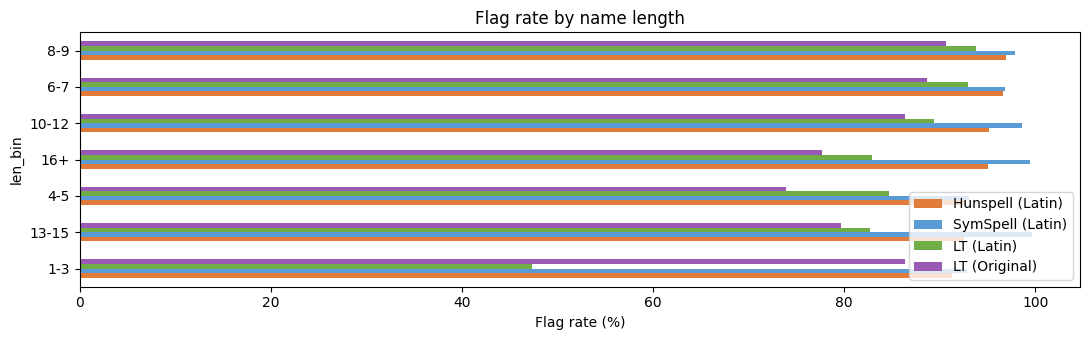

In [15]:
# Name length (binned)
bins   = [0, 3, 5, 7, 9, 12, 15, 999]
labels = ["1-3", "4-5", "6-7", "8-9", "10-12", "13-15", "16+"]
df_vis["len_bin"] = pd.cut(df_vis["name_len"], bins=bins, labels=labels)
plot_flag_rate(flag_rate_by(df_vis, "len_bin", top_n=len(labels)), "Flag rate by name length")

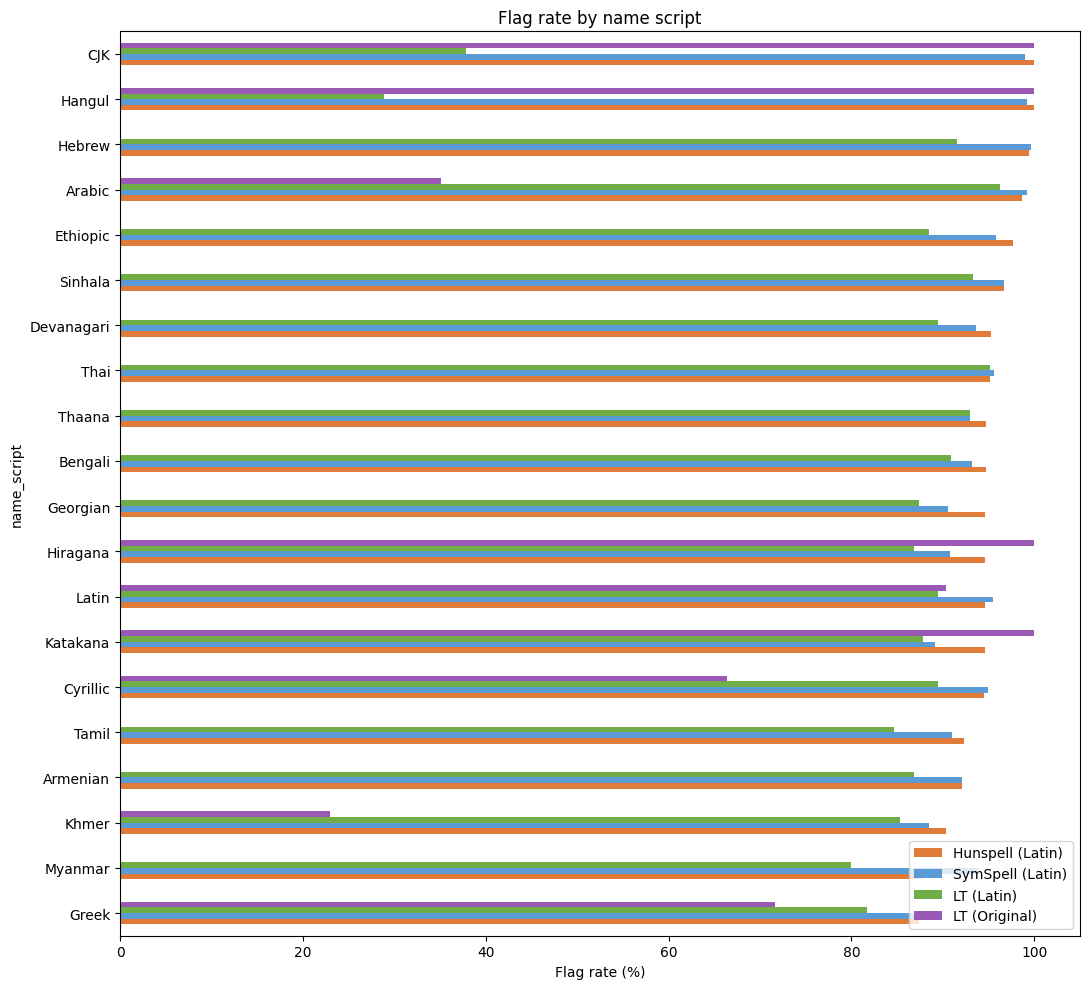

In [16]:
# Name script
plot_flag_rate(flag_rate_by(df_vis, "name_script"), "Flag rate by name script")

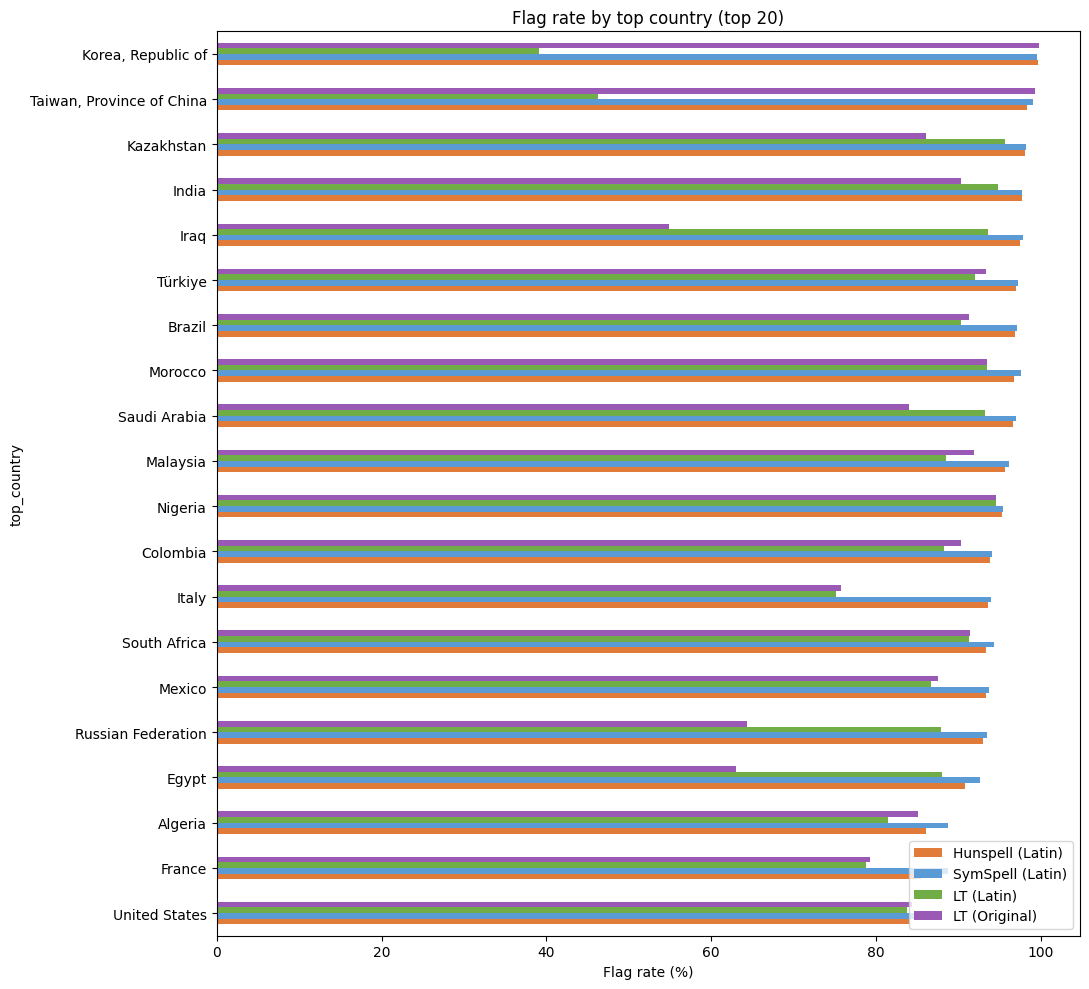

In [17]:
# Top country (top 20 by count)
plot_flag_rate(flag_rate_by(df_vis, "top_country", top_n=20), "Flag rate by top country (top 20)")

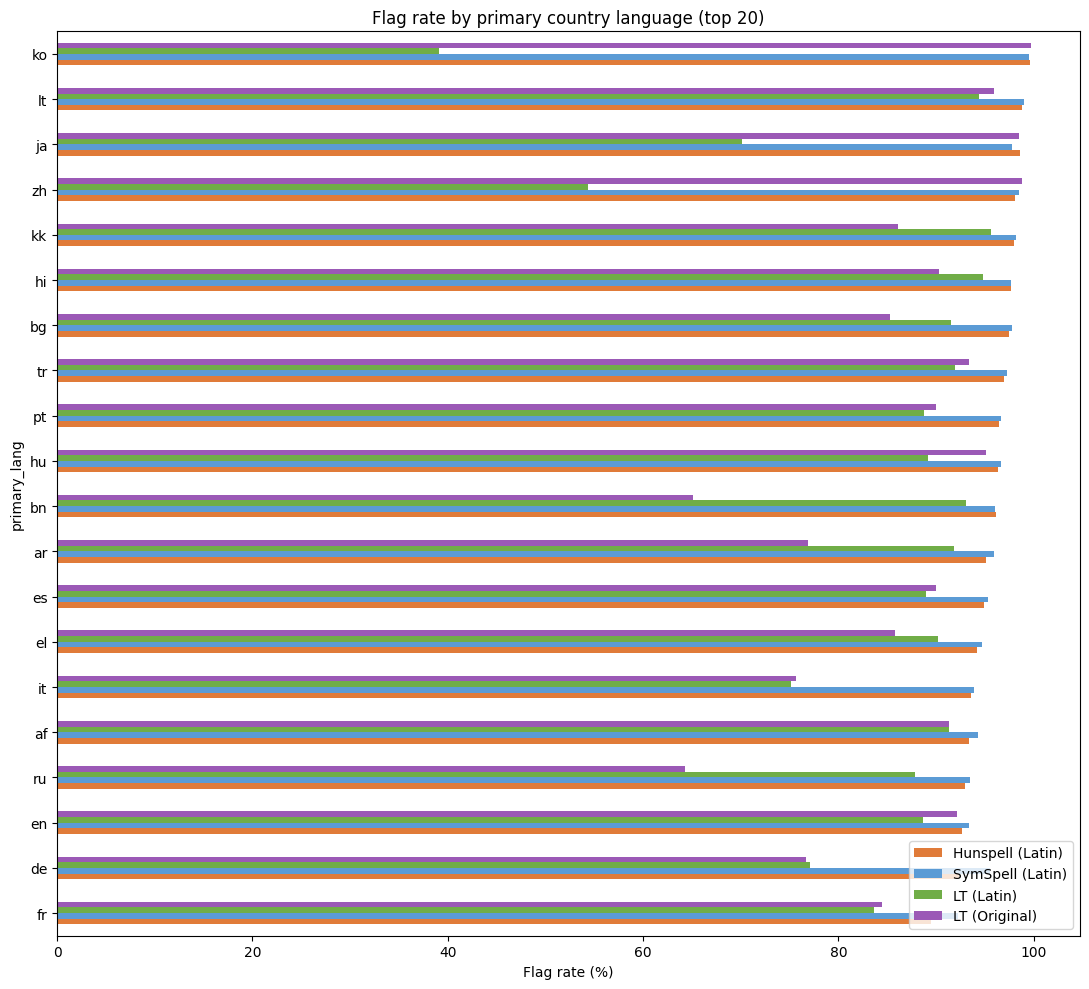

In [18]:
# Primary language of top country
plot_flag_rate(flag_rate_by(df_vis, "primary_lang", top_n=20), "Flag rate by primary country language (top 20)")

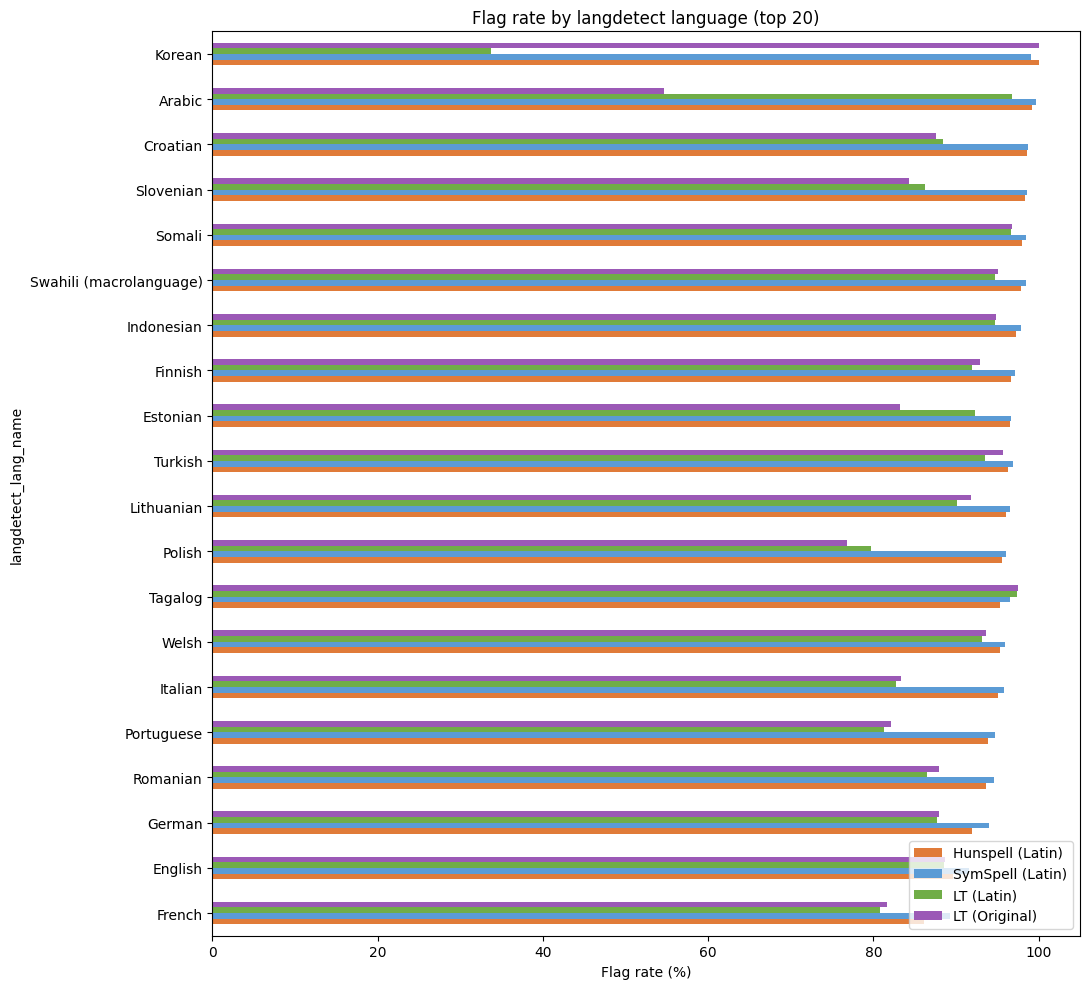

In [19]:
# Langdetect predicted language
plot_flag_rate(flag_rate_by(df_vis, "langdetect_lang_name", top_n=20), "Flag rate by langdetect language (top 20)")

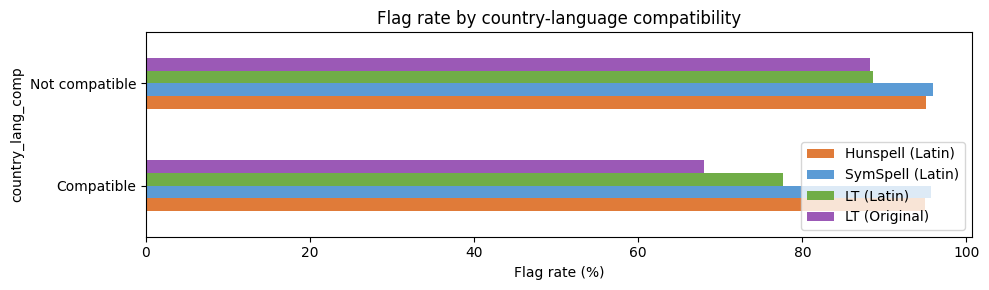

In [20]:
# Country-language compatibility
data = flag_rate_by(df_vis, "country_lang_comp", top_n=2)
data.index = data.index.map({True: "Compatible", False: "Not compatible"})
plot_flag_rate(data, "Flag rate by country-language compatibility", figsize=(10, 3))

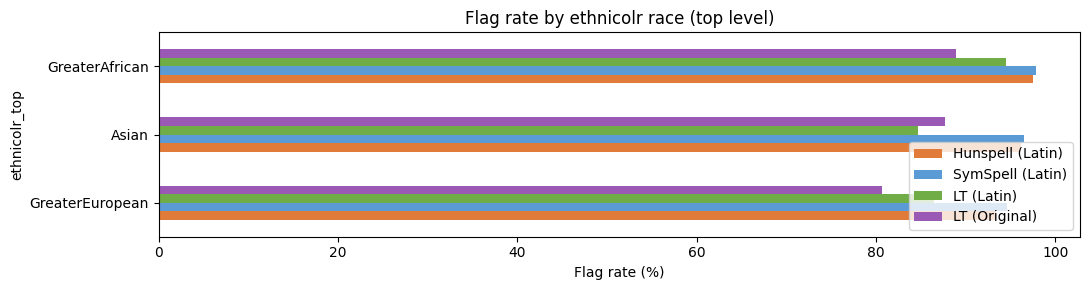

In [21]:
# Ethnicolr top-level race prediction
plot_flag_rate(flag_rate_by(df_vis, "ethnicolr_top"), "Flag rate by ethnicolr race (top level)")

## 5. Numerical breakdowns (full data, cleaned dataset)
Flag rate per group for every category level. Sorted by Hunspell flag rate descending. Delta columns show how much more/less each tool flags relative to Hunspell.

In [22]:
overall = {k: 100*(1 - df_vis[v].mean()) for k, v in CONDITIONS.items()}
print("Overall flag rates (cleaned, Condition B primary):")
for tool, rate in overall.items():
    print(f"  {tool:<20}: {rate:.1f}%")


def flag_table(frame, col):
    """Full numerical breakdown — all groups, all 4 conditions."""
    n_total = len(frame)
    grp    = frame.groupby(col, observed=True)
    rates  = 100 * (1 - grp[list(CONDITIONS.values())].mean())
    rates.columns = list(CONDITIONS.keys())
    rates["n"]   = grp.size()
    rates["n %"] = (rates["n"] / n_total * 100).round(1)
    # Δ columns: each tool vs Hunspell (Latin)
    for cond in ["SymSpell (Latin)", "LT (Latin)", "LT (Original)"]:
        rates[f"Δ{cond}"] = (rates[cond] - rates["Hunspell (Latin)"]).round(1)
    cols = ["n", "n %"] + list(CONDITIONS.keys()) + [f"Δ{c}" for c in ["SymSpell (Latin)","LT (Latin)","LT (Original)"]]
    return rates[cols].sort_values("Hunspell (Latin)", ascending=False).round(1)

Overall flag rates (cleaned, Condition B primary):
  Hunspell (Latin)    : 95.1%
  SymSpell (Latin)    : 95.8%
  LT (Latin)          : 86.7%
  LT (Original)       : 84.8%


In [23]:
print("=== Name script ===")
display(flag_table(df_vis, "name_script"))

=== Name script ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
name_script,,,,,,,,,
Kannada,4,0.0,100.0,100.0,100.0,0.0,0.0,0.0,-100.0
Malayalam,10,0.0,100.0,80.0,90.0,0.0,-20.0,-10.0,-100.0
Syriac,2,0.0,100.0,100.0,100.0,0.0,0.0,0.0,-100.0
SUNDANESE,1,0.0,100.0,100.0,0.0,0.0,0.0,-100.0,-100.0
RUNIC,1,0.0,100.0,100.0,100.0,0.0,0.0,0.0,-100.0
Oriya,2,0.0,100.0,100.0,50.0,0.0,0.0,-50.0,-100.0
NKO,1,0.0,100.0,100.0,100.0,0.0,0.0,0.0,-100.0
VAI,2,0.0,100.0,100.0,100.0,50.0,0.0,0.0,-50.0
CANADIAN,4,0.0,100.0,100.0,100.0,0.0,0.0,0.0,-100.0


In [24]:
print("=== Name length (binned) ===")
display(flag_table(df_vis, "len_bin"))

=== Name length (binned) ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
len_bin,,,,,,,,,
8-9,107396,18.8,96.9,97.9,93.9,90.7,1.0,-3.0,-6.2
6-7,227344,39.8,96.6,96.9,93.0,88.7,0.3,-3.6,-7.9
10-12,32389,5.7,95.2,98.7,89.4,86.4,3.5,-5.8,-8.8
16+,757,0.1,95.1,99.5,83.0,77.7,4.4,-12.2,-17.4
4-5,149670,26.2,92.8,93.0,84.7,73.9,0.2,-8.1,-18.9
13-15,4139,0.7,92.5,99.7,82.7,79.6,7.2,-9.8,-12.9
1-3,49498,8.7,91.3,92.9,47.3,86.4,1.6,-44.0,-4.9


In [25]:
print("=== Top country ===")
display(flag_table(df_vis, "top_country"))

=== Top country ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
top_country,,,,,,,,,
Turkmenistan,937,0.2,99.8,99.9,98.9,97.0,0.1,-0.9,-2.8
Yemen,2456,0.4,99.7,99.6,97.7,54.3,-0.1,-2.0,-45.4
"Korea, Republic of",13751,2.4,99.6,99.5,39.1,99.7,-0.1,-60.5,0.1
Indonesia,4278,0.7,99.5,99.8,98.2,98.2,0.3,-1.4,-1.4
Lebanon,1159,0.2,99.1,99.6,94.7,92.1,0.4,-4.5,-7.1
...,...,...,...,...,...,...,...,...,...
France,13583,2.4,85.4,88.7,78.8,79.2,3.3,-6.6,-6.2
United States,25106,4.4,84.1,84.6,83.8,84.4,0.6,-0.3,0.3
Norway,1852,0.3,83.4,98.0,72.9,70.0,14.6,-10.4,-13.3


In [26]:
print("=== Primary country language ===")
display(flag_table(df_vis, "primary_lang"))

=== Primary country language ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
primary_lang,,,,,,,,,
tk,937,0.2,99.8,99.9,98.9,97.0,0.1,-0.9,-2.8
ko,13751,2.4,99.6,99.5,39.1,99.7,-0.1,-60.5,0.1
id,4278,0.7,99.5,99.8,98.2,98.2,0.3,-1.4,-1.4
ps,4711,0.8,98.9,99.0,98.4,60.5,0.1,-0.5,-38.4
dv,3660,0.6,98.8,99.1,98.3,94.3,0.3,-0.5,-4.4
lt,7515,1.3,98.7,99.0,94.4,95.9,0.2,-4.3,-2.8
sq,6776,1.2,98.7,99.0,94.3,95.3,0.2,-4.4,-3.4
ja,7878,1.4,98.6,97.8,70.1,98.5,-0.8,-28.5,-0.1
az,5952,1.0,98.6,99.0,96.3,97.5,0.5,-2.3,-1.1


In [27]:
print("=== Langdetect predicted language ===")
display(flag_table(df_vis, "langdetect_lang_name"))

=== Langdetect predicted language ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
langdetect_lang_name,,,,,,,,,
Malayalam,10,0.0,100.0,80.0,90.0,0.0,-20.0,-10.0,-100.0
Kannada,4,0.0,100.0,100.0,100.0,0.0,0.0,0.0,-100.0
Chinese,4437,0.8,100.0,99.3,38.5,100.0,-0.7,-61.5,0.0
Korean,27912,4.9,100.0,99.1,33.7,100.0,-0.9,-66.3,0.0
Hebrew,4209,0.7,99.4,99.6,91.5,0.0,0.2,-7.9,-99.4
Arabic,19195,3.4,99.2,99.6,96.7,54.7,0.5,-2.4,-44.5
Croatian,13134,2.3,98.6,98.7,88.4,87.6,0.1,-10.2,-11.0
Slovenian,12742,2.2,98.3,98.5,86.3,84.3,0.2,-12.0,-14.0
Persian,8432,1.5,98.1,98.6,96.4,0.8,0.6,-1.6,-97.2


In [28]:
print("=== Country-language compatibility ===")
display(flag_table(df_vis, "country_lang_comp"))

=== Country-language compatibility ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
country_lang_comp,,,,,,,,,
False,472763,82.8,95.1,95.9,88.6,88.3,0.8,-6.5,-6.9
True,98430,17.2,95.0,95.6,77.6,68.0,0.6,-17.4,-27.0


In [29]:
print("=== Ethnicolr race (top level) ===")
display(flag_table(df_vis, "ethnicolr_top"))

=== Ethnicolr race (top level) ===


,n,n %,Hunspell (Latin),SymSpell (Latin),LT (Latin),LT (Original),ΔSymSpell (Latin),ΔLT (Latin),ΔLT (Original)
ethnicolr_top,,,,,,,,,
GreaterAfrican,71174,12.5,97.5,97.9,94.5,88.9,0.3,-3.1,-8.6
Asian,249337,43.7,96.1,96.5,84.7,87.7,0.4,-11.4,-8.5
GreaterEuropean,250666,43.9,93.4,94.6,86.5,80.7,1.2,-6.9,-12.7


## 6. Tool comparison: flag rate vs group frequency
Two comparison designs:
- **B/B/B**: Hunspell Latin vs SymSpell Latin vs LT Latin — all tools on the same transliterated input
- **B/B/A**: Hunspell Latin vs SymSpell Latin vs LT Original — LT on naturally-cased names (captures proper-noun recognition for Latin; silent pass-through for non-Latin)

Scatter plots show whether a group's representation in the dataset predicts how heavily it is flagged.
X-axis is log-scaled; each point is one group (country / language).

In [30]:
def scatter_freq_flag(frame, col, title):
    grp   = frame.groupby(col)
    ns    = grp.size().rename("n")
    rates = 100 * (1 - grp[list(CONDITIONS.values())].mean())
    rates.columns = list(CONDITIONS.keys())
    data  = pd.concat([ns, rates], axis=1).dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    for cond, color in zip(CONDITIONS.keys(), COLORS):
        ax.scatter(data["n"], data[cond], label=cond, color=color,
                   alpha=0.75, edgecolors="white", linewidths=0.4, s=60)
    ax.set_xscale("log")
    ax.set_xlabel(f"Names in group (log scale)")
    ax.set_ylabel("Flag rate (%)")
    ax.set_ylim(-2, 102)
    ax.axhline(50, color="grey", linewidth=0.5, linestyle="--")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

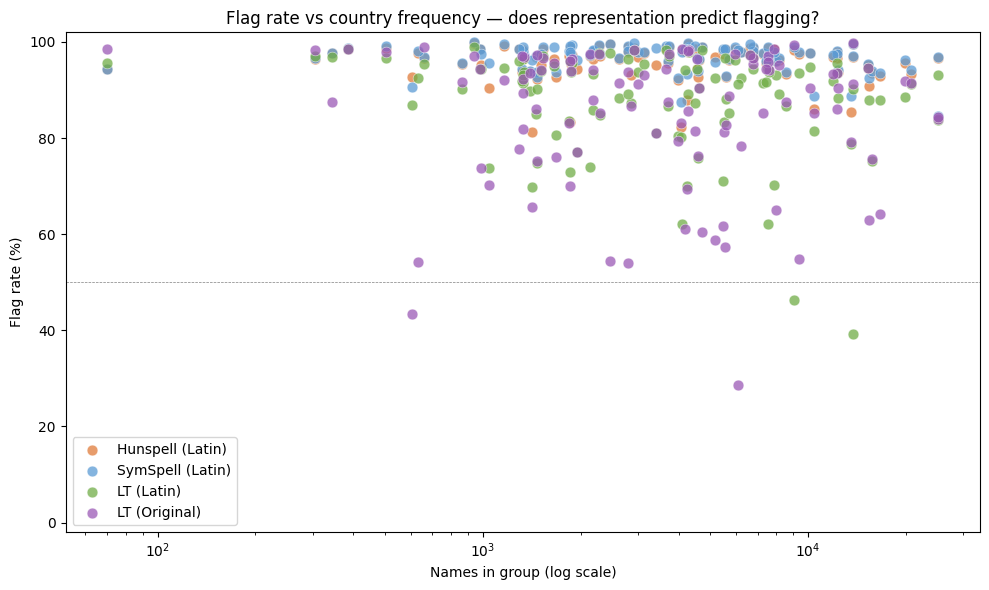

In [31]:
# Scatter: top_country frequency vs flag rate
scatter_freq_flag(df_vis, "top_country",
    "Flag rate vs country frequency — does representation predict flagging?")

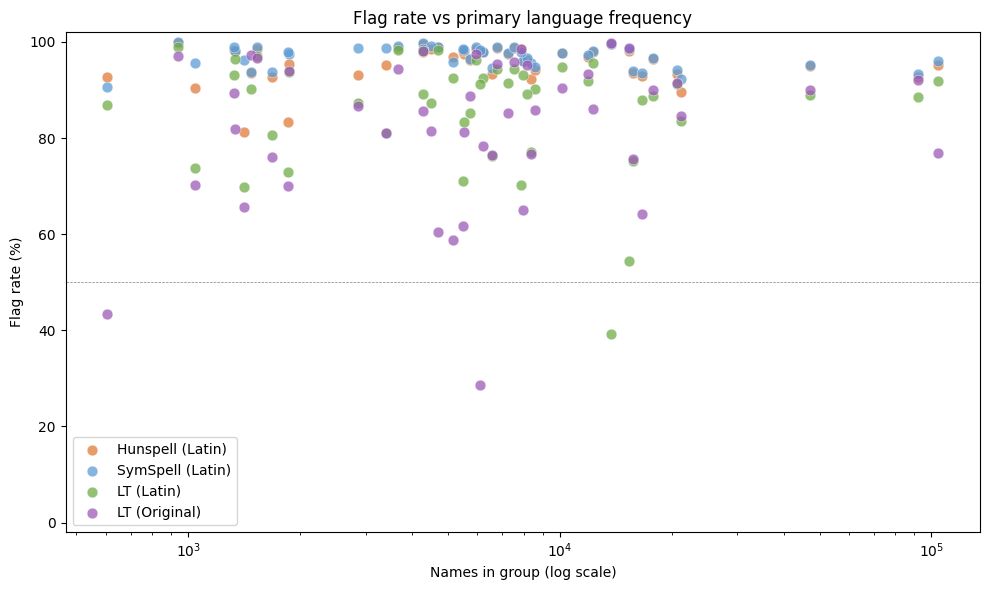

In [32]:
# Scatter: primary country language frequency vs flag rate
scatter_freq_flag(df_vis, "primary_lang",
    "Flag rate vs primary language frequency")

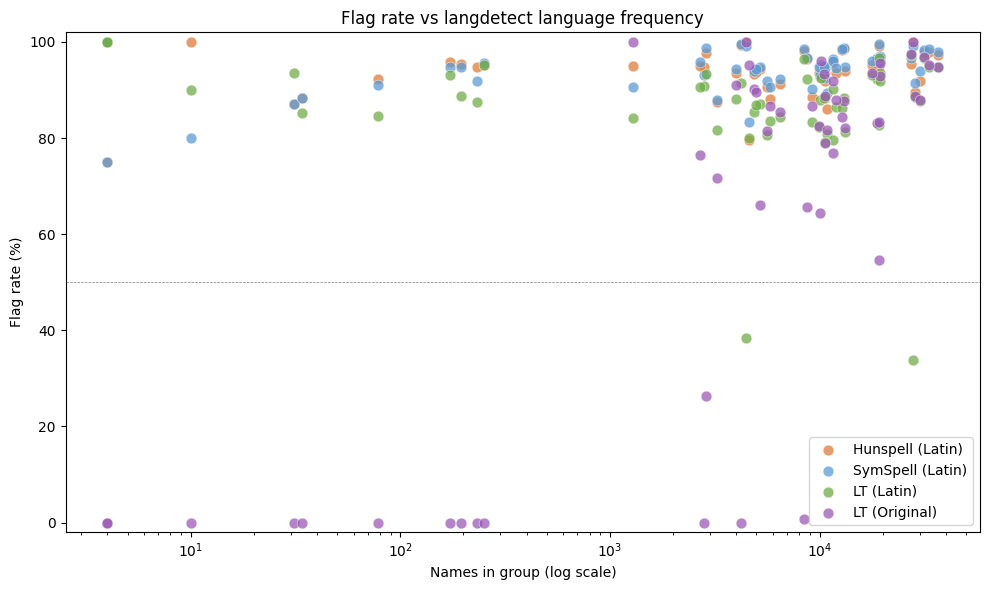

In [33]:
# Scatter: langdetect language frequency vs flag rate
scatter_freq_flag(df_vis, "langdetect_lang_name",
    "Flag rate vs langdetect language frequency")

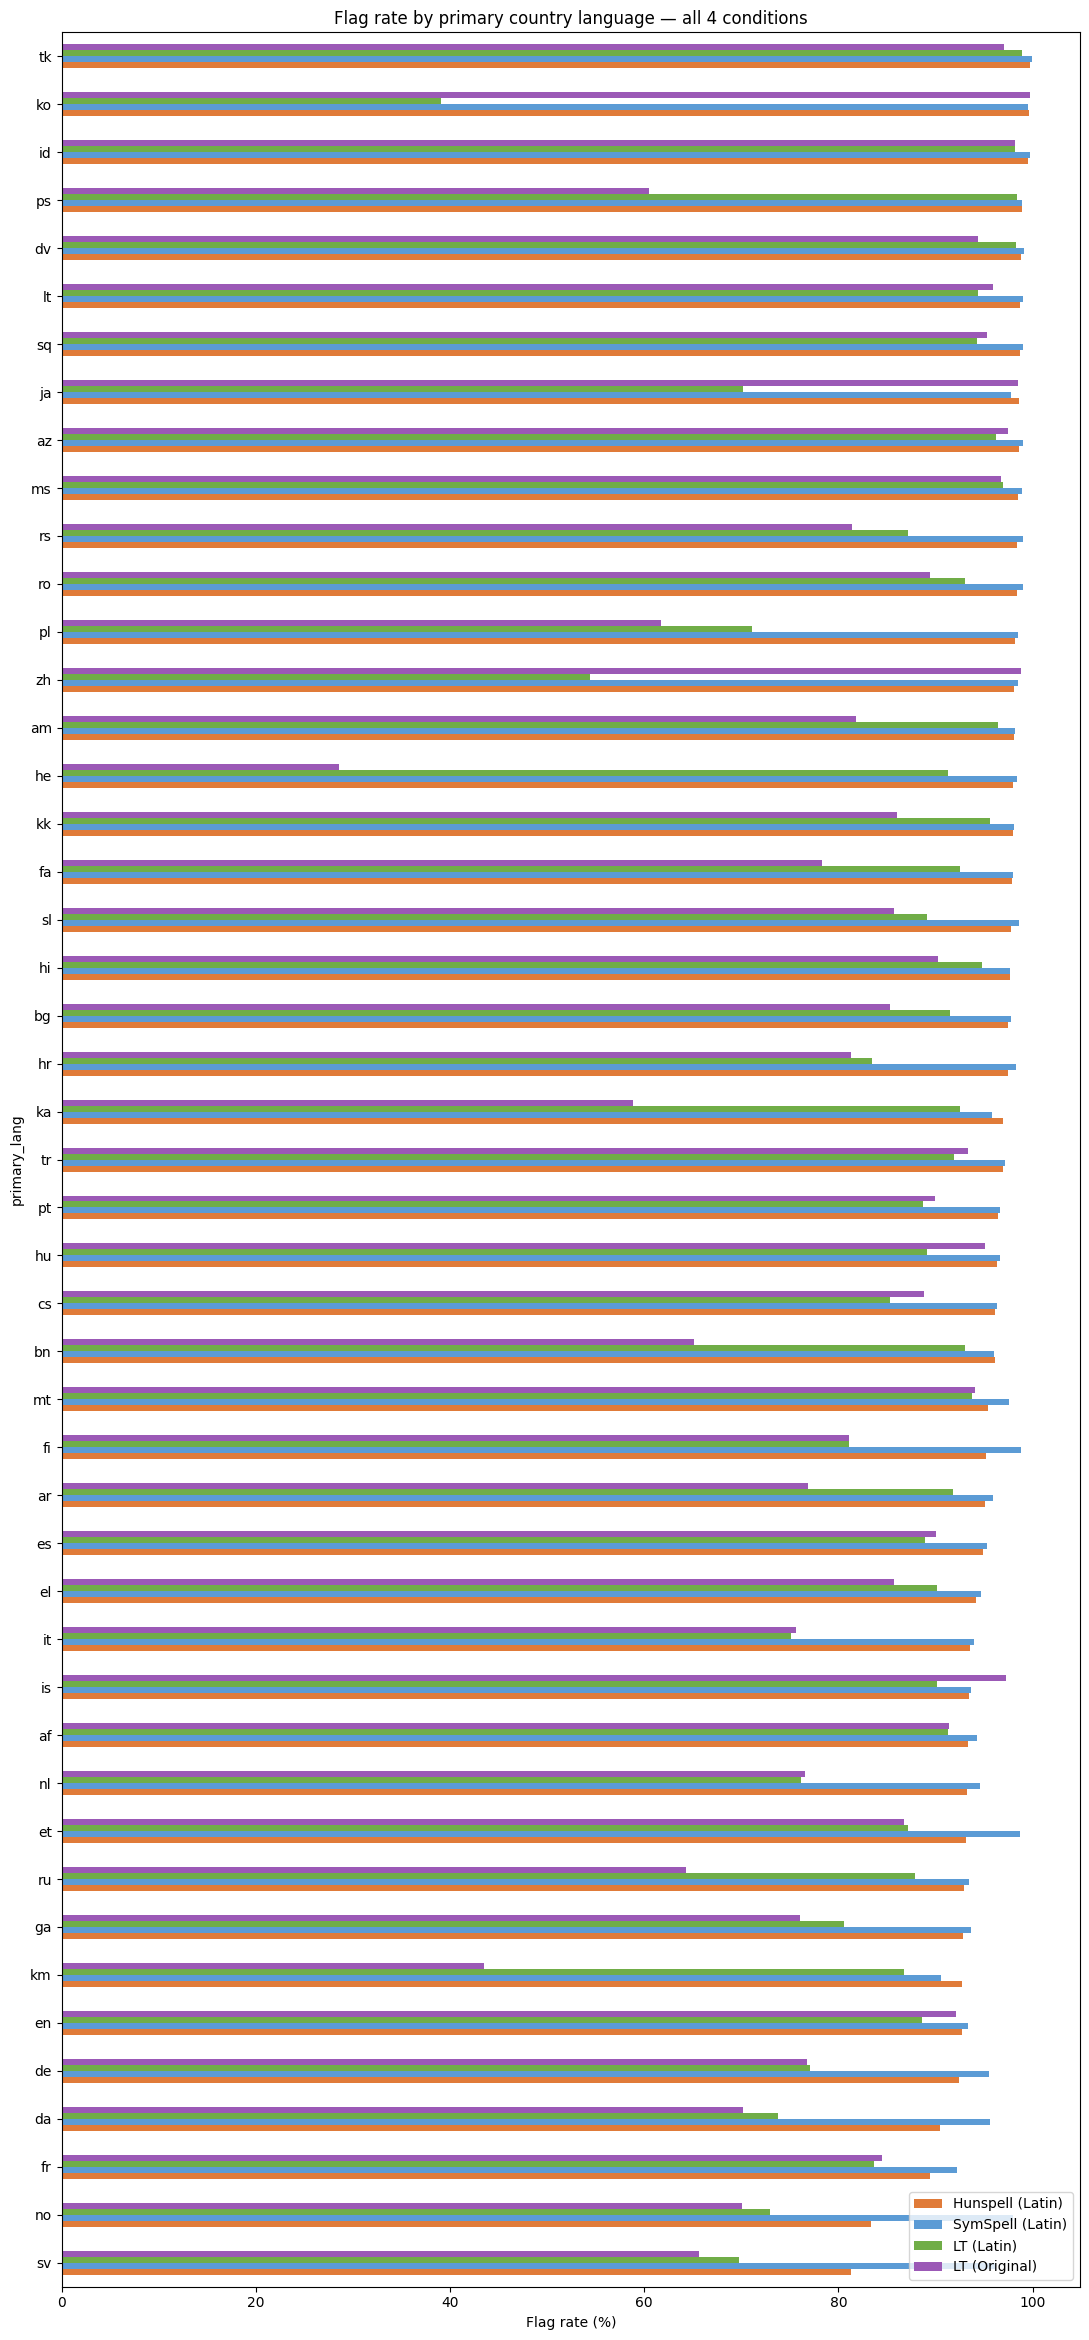

In [34]:
# Grouped bar: flag rate by primary language — all 4 conditions, all groups
data = flag_rate_by(df_vis, "primary_lang", top_n=len(df_vis["primary_lang"].dropna().unique()))
plot_flag_rate(data, "Flag rate by primary country language — all 4 conditions")